In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set_theme(style="whitegrid", palette="muted")

In [2]:
df_final_demo = pd.read_csv("/Users/lewisclark/Downloads/df_final_demo.txt", delimiter=",")
df_final_exp = pd.read_csv("/Users/lewisclark/Downloads/df_final_experiment_clients.txt", delimiter=",")
df_final_web_pt1 = pd.read_csv("/Users/lewisclark/Downloads/df_final_web_data_pt_1.txt", delimiter=",")
df_final_web_pt2 = pd.read_csv("/Users/lewisclark/Downloads/df_final_web_data_pt_2.txt", delimiter=",")

In [3]:
df_final_web_data = pd.concat([df_final_web_pt1, df_final_web_pt2], ignore_index=True)
df_final_web_data

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
...,...,...,...,...,...
755400,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:46:10
755401,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:45:29
755402,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24 18:44:51
755403,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:44:34


In [4]:
df_merged = df_final_demo.merge(df_final_exp, on="client_id", how="left")
df_merged

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control
...,...,...,...,...,...,...,...,...,...,...
70604,7993686,4.0,56.0,38.5,U,3.0,1411062.68,5.0,5.0,NaN
70605,8981690,12.0,148.0,31.0,M,2.0,101867.07,6.0,6.0,NaN
70606,333913,16.0,198.0,61.5,F,2.0,40745.00,3.0,3.0,NaN
70607,1573142,21.0,255.0,68.0,M,3.0,475114.69,4.0,4.0,NaN


In [5]:
df_merged.info(), df_merged.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  object 
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
 9   Variation         50500 non-null  object 
dtypes: float64(7), int64(1), object(2)
memory usage: 5.4+ MB


(None,
 client_id               0
 clnt_tenure_yr         14
 clnt_tenure_mnth       14
 clnt_age               15
 gendr                  14
 num_accts              14
 bal                    14
 calls_6_mnth           14
 logons_6_mnth          14
 Variation           20109
 dtype: int64)

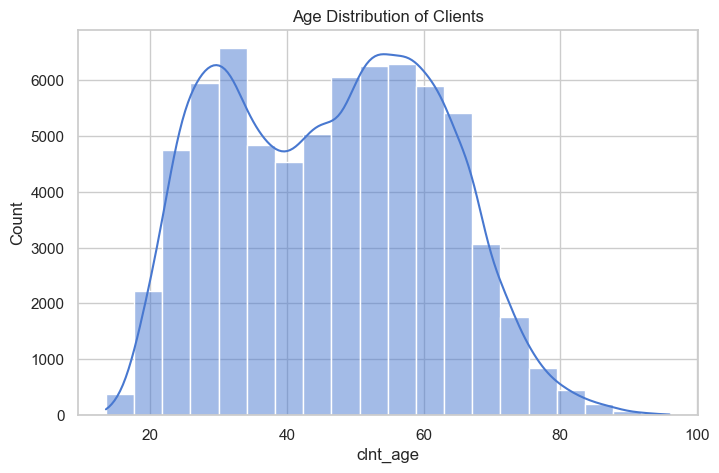

In [6]:
# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df_merged["clnt_age"], bins=20, kde=True)
plt.title("Age Distribution of Clients")
plt.show()

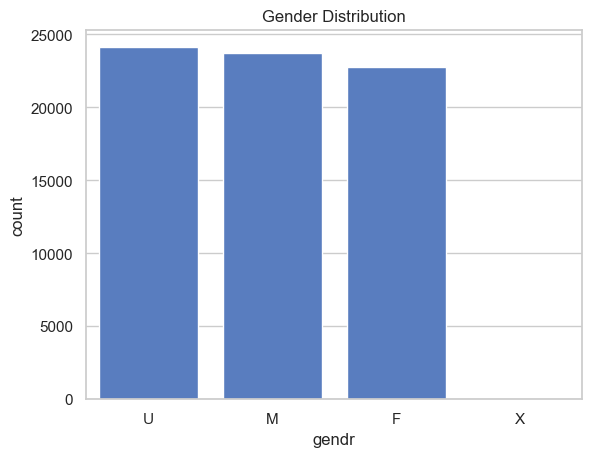

In [7]:
sns.countplot(data=df_merged, x="gendr")
plt.title("Gender Distribution")
plt.show()

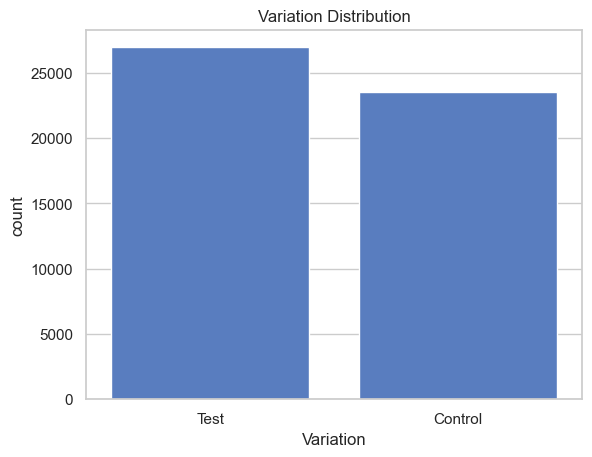

In [8]:
sns.countplot(data=df_merged, x="Variation")
plt.title("Variation Distribution")
plt.show()

In [9]:
df_final_web_data["date_time"] = pd.to_datetime(df_final_web_data["date_time"])
df_final_web_data["Date"] = df_final_web_data["date_time"].dt.date
df_final_web_data["Time"] = df_final_web_data["date_time"].dt.time

In [10]:
df_final_web_data.head()  # Display the first few rows of the web data

,client_id,visitor_id,visit_id,process_step,date_time,Date,Time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,2017-04-17,15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,2017-04-17,15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,2017-04-17,15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,2017-04-17,15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,2017-04-17,15:18:04


In [11]:
df_merged

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control
...,...,...,...,...,...,...,...,...,...,...
70604,7993686,4.0,56.0,38.5,U,3.0,1411062.68,5.0,5.0,NaN
70605,8981690,12.0,148.0,31.0,M,2.0,101867.07,6.0,6.0,NaN
70606,333913,16.0,198.0,61.5,F,2.0,40745.00,3.0,3.0,NaN
70607,1573142,21.0,255.0,68.0,M,3.0,475114.69,4.0,4.0,NaN


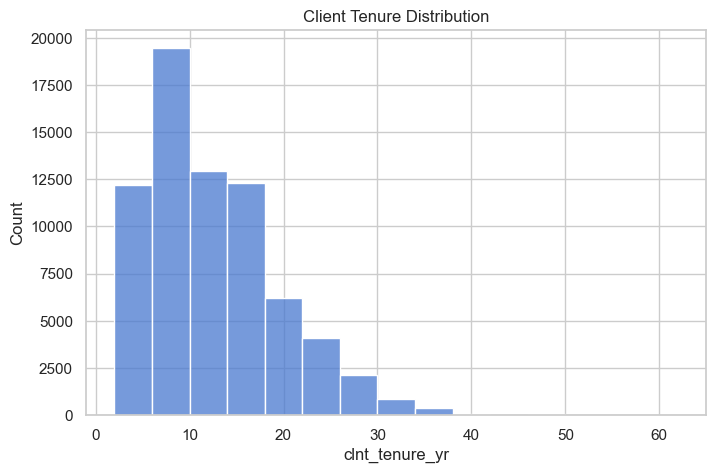

In [12]:
# Tenure (years with Vanguard)

plt.figure(figsize=(8,5))
sns.histplot(df_merged["clnt_tenure_yr"], bins=15, kde=False)
plt.title("Client Tenure Distribution")
plt.show()

In [13]:
df_merged["tenure_category"] = np.where(df_merged["clnt_tenure_yr"] < 5, "New", "Long-standing") # Categorizing tenure
df_merged["tenure_category"].value_counts()

tenure_category
Long-standing    65392
New               5217
Name: count, dtype: int64

In [14]:
df_merged.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,tenure_category
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test,Long-standing
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control,Long-standing
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test,Long-standing
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test,Long-standing
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control,Long-standing


In [15]:
df_final_web_data.head(10)  # Display the first few rows of the web data

,client_id,visitor_id,visit_id,process_step,date_time,Date,Time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,2017-04-17,15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,2017-04-17,15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,2017-04-17,15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,2017-04-17,15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,2017-04-17,15:18:04
5,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:17:15,2017-04-17,15:17:15
6,9988021,580560515_7732621733,781255054_21935453173_531117,step_1,2017-04-17 15:17:01,2017-04-17,15:17:01
7,9988021,580560515_7732621733,781255054_21935453173_531117,start,2017-04-17 15:16:22,2017-04-17,15:16:22
8,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05 13:10:05,2017-04-05,13:10:05
9,8320017,39393514_33118319366,960651974_70596002104_312201,step_3,2017-04-05 13:09:43,2017-04-05,13:09:43


In [16]:
completed_clients = df_final_web_data[df_final_web_data["process_step"]=="confirm"]["client_id"].unique()
df_merged["completed"] = df_merged["client_id"].isin(completed_clients).astype(int)

completion_rate = df_merged.groupby("client_id")["completed"].mean()
completion_rate

client_id
169        1.0
555        1.0
647        1.0
722        1.0
934        0.0
          ... 
9999400    1.0
9999626    0.0
9999729    1.0
9999832    0.0
9999839    1.0
Name: completed, Length: 70609, dtype: float64

In [17]:
df_merged.head(2)

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,tenure_category,completed
0,836976,6.0,73.0,60.5,U,2.0,45105.3,6.0,9.0,Test,Long-standing,1
1,2304905,7.0,94.0,58.0,U,2.0,110860.3,6.0,9.0,Control,Long-standing,1


/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/3156044541.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_completion = df_merged.groupby("age_group")["completed"].mean().reset_index()
/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/3156044541.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_completion, x="age_group", y="completed", palette="viridis")


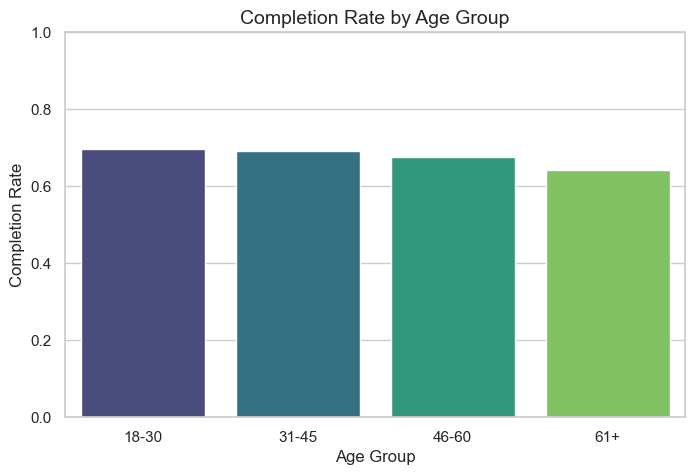

In [98]:
df_merged["age_group"] = pd.cut(df_merged["clnt_age"], bins=[18,30,45,60,np.inf], labels=["18-30","31-45","46-60","61+"])

age_completion = df_merged.groupby("age_group")["completed"].mean().reset_index()

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=age_completion, x="age_group", y="completed", palette="viridis")
plt.title("Completion Rate by Age Group", fontsize=14)
plt.ylabel("Completion Rate")
plt.ylim(0,1)
plt.xlabel("Age Group")
plt.show()

/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/2036891681.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  completion_by_age = df_merged.groupby(["age_group", "Variation"])["completed"].mean().reset_index()


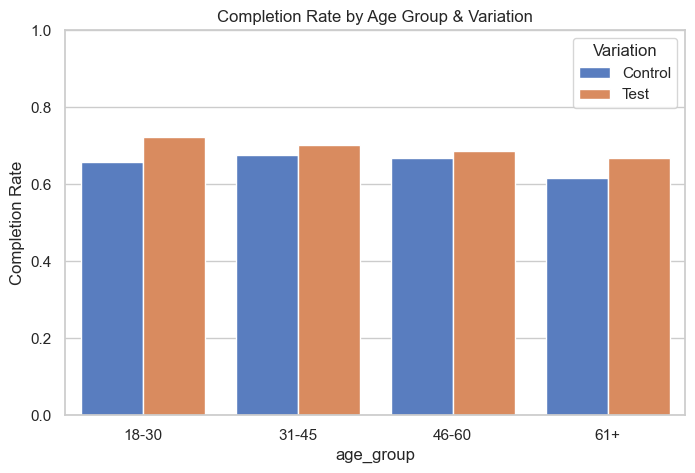

In [99]:
completion_by_age = df_merged.groupby(["age_group", "Variation"])["completed"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=completion_by_age, x="age_group", y="completed", hue="Variation")
plt.title("Completion Rate by Age Group & Variation")
plt.ylabel("Completion Rate")
plt.ylim(0,1)
plt.show()

In [20]:
overall_completion = df_merged["completed"].mean()
print("Overall Completion Rate:", round(overall_completion*100, 2), "%") 
# Overall completion rate. mean() returns the average of the 'completed' column, which is 1 for completed clients and 0 for non-completed clients

Overall Completion Rate: 67.7 %


In [21]:
# Completion rate by variation(experiment groups)
completion_by_variation = df_merged.groupby("Variation")["completed"].mean().reset_index()
completion_by_variation

,Variation,completed
0,Control,0.655873
1,Test,0.692932


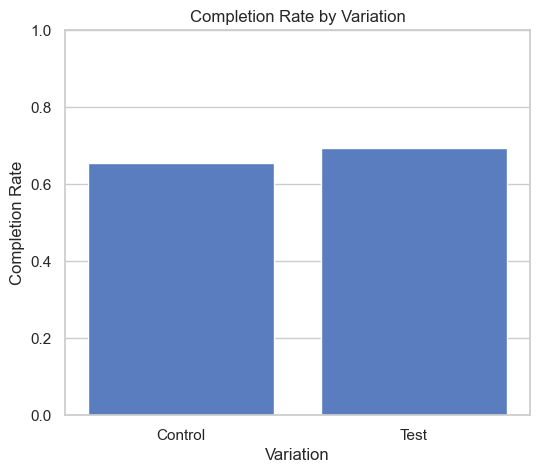

In [22]:
plt.figure(figsize=(6,5))
sns.barplot(data=completion_by_variation, x="Variation", y="completed")
plt.title("Completion Rate by Variation")
plt.ylabel("Completion Rate")
plt.ylim(0,1) # Set y-axis limits to [0, 1] for better visualization
plt.show()

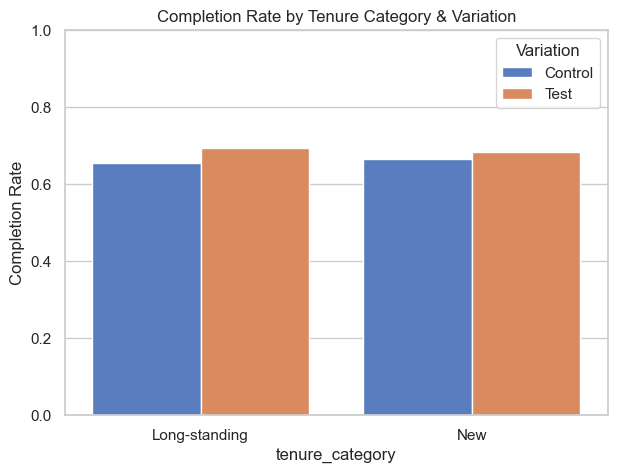

In [23]:
completion_by_tenure = df_merged.groupby(["tenure_category", "Variation"])["completed"].mean().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(data=completion_by_tenure, x="tenure_category", y="completed", hue="Variation")
plt.title("Completion Rate by Tenure Category & Variation")
plt.ylabel("Completion Rate")
plt.ylim(0,1)
plt.show()

/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/2961676787.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tenure_completion, x="tenure_category", y="completed", palette="magma")


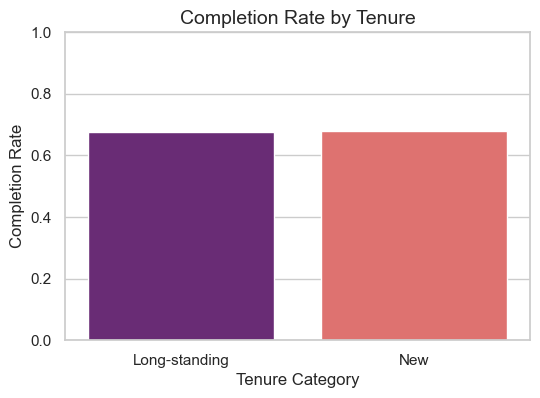

In [24]:
tenure_completion = df_merged.groupby("tenure_category")["completed"].mean().reset_index()

# Plot
plt.figure(figsize=(6,4))
sns.barplot(data=tenure_completion, x="tenure_category", y="completed", palette="magma")
plt.title("Completion Rate by Tenure", fontsize=14)
plt.ylabel("Completion Rate")
plt.ylim(0,1)
plt.xlabel("Tenure Category")
plt.show()

In [25]:
tenure_completion

,tenure_category,completed
0,Long-standing,0.676841
1,New,0.678551


Time spent on each step

In [26]:
df_final_web_data.head()  # Display the first few rows of the web data

,client_id,visitor_id,visit_id,process_step,date_time,Date,Time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,2017-04-17,15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,2017-04-17,15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,2017-04-17,15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,2017-04-17,15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,2017-04-17,15:18:04


In [27]:
### extract the number from process_step - extract digits (if any)
df_final_web_data['step_num'] = df_final_web_data['process_step'].str.extract('(\d+)')

### handle string step: start = 0, confirm = 4
df_final_web_data.loc[df_final_web_data['process_step'] == 'start', 'step_num'] = 0
df_final_web_data.loc[df_final_web_data['process_step'] == 'confirm', 'step_num'] = 4

### convert safely to nullable integer
df_final_web_data['step_num'] = pd.to_numeric(df_final_web_data['step_num'], errors='coerce').astype('Int64')

### put in order by client_id, visit_id, date_time 
df_final_web_data = df_final_web_data.sort_values(by=['client_id', 'visit_id', 'date_time'])

### find and flag backward movements as errors
df_final_web_data['error_flag'] = (
    df_final_web_data
    .groupby(['client_id', 'visit_id'])['step_num']
    .diff()
    .apply(lambda x: 1 if pd.notna(x) and x < 0 else 0)
)

df_final_web_data

### 1 = error, backwards step
### 0 = no error, forward or same step

,client_id,visitor_id,visit_id,process_step,date_time,Date,Time,step_num,error_flag
285515,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36,2017-04-12,20:19:36,0,0
285514,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45,2017-04-12,20:19:45,1,0
285513,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31,2017-04-12,20:20:31,2,0
285512,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05,2017-04-12,20:22:05,3,0
285511,169,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09,2017-04-12,20:23:09,4,0
...,...,...,...,...,...,...,...,...,...
648533,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:40:08,2017-06-01,22:40:08,1,0
648532,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:41:28,2017-06-01,22:41:28,1,0
648531,9999875,738878760_1556639849,931268933_219402947_599432,step_2,2017-06-01 22:41:47,2017-06-01,22:41:47,2,0
648530,9999875,738878760_1556639849,931268933_219402947_599432,step_3,2017-06-01 22:44:58,2017-06-01,22:44:58,3,0


In [28]:
# define the step order as an array
step_order = ["start", "step_1", "step_2", "step_3", "confirm"]
df_final_web_data["process_step"] = pd.Categorical(df_final_web_data["process_step"], categories=step_order, ordered=True)

In [29]:
# Ensure datetime is correct
df_final_web_data["date_time"] = pd.to_datetime(df_final_web_data["date_time"])

# Sort by client, visit, and step order (not just timestamp)
df_final_web_data = df_final_web_data.sort_values(
    ["client_id", "visit_id", "step_num"]
)

# Calculate step duration
df_final_web_data["step_duration"] = (
    df_final_web_data.groupby(["client_id", "visit_id"])["date_time"]
    .diff()
    .dt.total_seconds()
)

# Average step duration
avg_step_duration = (
    df_final_web_data.groupby("process_step")["step_duration"]
    .mean()
    .reset_index()
)

avg_step_duration

/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/1112249525.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_final_web_data.groupby("process_step")["step_duration"]


,process_step,step_duration
0,start,194.603802
1,step_1,7.515681
2,step_2,29.256520
3,step_3,83.450609
4,confirm,129.909461


/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/1260807267.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


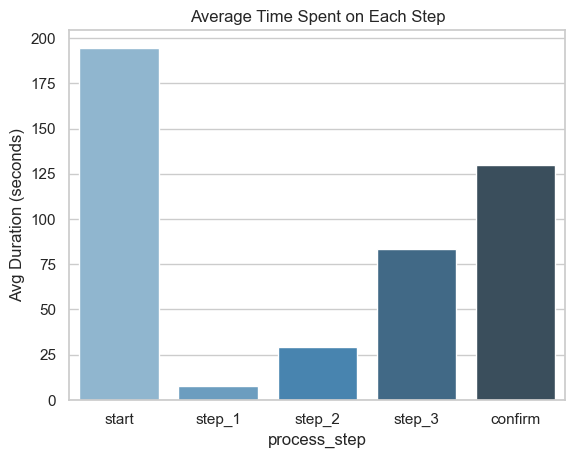

In [30]:
sns.barplot(
    data=avg_step_duration,
    x="process_step",
    y="step_duration",
    palette="Blues_d"
)
plt.title("Average Time Spent on Each Step")
plt.ylabel("Avg Duration (seconds)")
plt.show()

In [31]:
df_final_web_data['process_step'].isnull().any()

np.False_

In [32]:
df_final_web_data['error_flag'].value_counts()

error_flag
0    692445
1     62960
Name: count, dtype: int64

In [33]:
### calculating the error rate

error_rate = df_final_web_data['error_flag'].mean() * 100
print(error_rate)

8.334601968480484


In [34]:
# Make sure step_duration exists
df_final_web_data["date_time"] = pd.to_datetime(df_final_web_data["date_time"])
df_final_web_data = df_final_web_data.sort_values(["client_id", "visit_id", "step_num"])
df_final_web_data["step_duration"] = (
    df_final_web_data.groupby(["client_id", "visit_id"])["date_time"].diff().dt.total_seconds()
)

In [35]:
### merging the two dataframes to 'df_combined'

df_combined = pd.merge(
    df_final_web_data,
    df_merged,
    on='client_id',
    how='left'
)

In [36]:
df_combined.head()

,client_id,visitor_id,visit_id,process_step,date_time,Date,Time,step_num,error_flag,step_duration,...,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,tenure_category,completed,age_group
0,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36,2017-04-12,20:19:36,0,0,NaN,...,47.5,M,2.0,501570.72,4.0,4.0,NaN,Long-standing,1.0,46-60
1,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45,2017-04-12,20:19:45,1,0,9.0,...,47.5,M,2.0,501570.72,4.0,4.0,NaN,Long-standing,1.0,46-60
2,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31,2017-04-12,20:20:31,2,0,46.0,...,47.5,M,2.0,501570.72,4.0,4.0,NaN,Long-standing,1.0,46-60
3,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05,2017-04-12,20:22:05,3,0,94.0,...,47.5,M,2.0,501570.72,4.0,4.0,NaN,Long-standing,1.0,46-60
4,169,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09,2017-04-12,20:23:09,4,0,64.0,...,47.5,M,2.0,501570.72,4.0,4.0,NaN,Long-standing,1.0,46-60


In [37]:
df_combined["Variation"].isna().sum()

np.int64(434096)

In [38]:
# Proportion of missing Variation
missing_ratio = df_combined["Variation"].isna().mean()
missing_ratio

np.float64(0.5746533316565287)

57 % OF THE ROWS HAS NaN VALUES ON VARIATION COLUMN. MAYBE WE CAN LABEL THEM AS UNKNOWN INSTEAD OF DROPPING

In [39]:
df_combined = df_combined.dropna(subset=["Variation"])


COMBINED COMPARISONS

TENURE

In [40]:
tenure_completion_combined = (
    df_combined.groupby("tenure_category")["completed"]
    .mean()
    .reset_index()
)
tenure_completion_combined

,tenure_category,completed
0,Long-standing,0.765658
1,New,0.770254


/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/1161972191.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


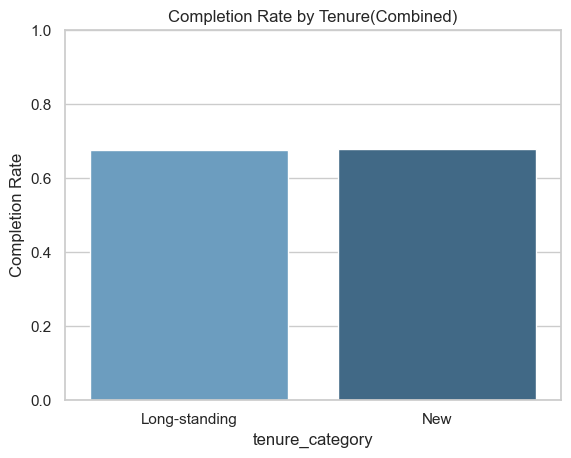

In [41]:
sns.barplot(
    data=tenure_completion,
    x="tenure_category",
    y="completed",
    palette="Blues_d"
)
plt.title("Completion Rate by Tenure(Combined)")
plt.ylabel("Completion Rate")
plt.ylim(0, 1)
plt.show()

COMPLETION PER VISIT

In [43]:
completion_per_visit = df_combined.groupby(['visit_id', 'Variation'])['completed'].max().reset_index()
completion_rate_variation = completion_per_visit.groupby('Variation')['completed'].mean()
completion_rate_variation

Variation
Control    0.672901
Test       0.710066
Name: completed, dtype: float64

Treshold is less than 5%

/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/2604840553.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=completion_rate_variation, x="Variation", y="completed", palette="Dark2")


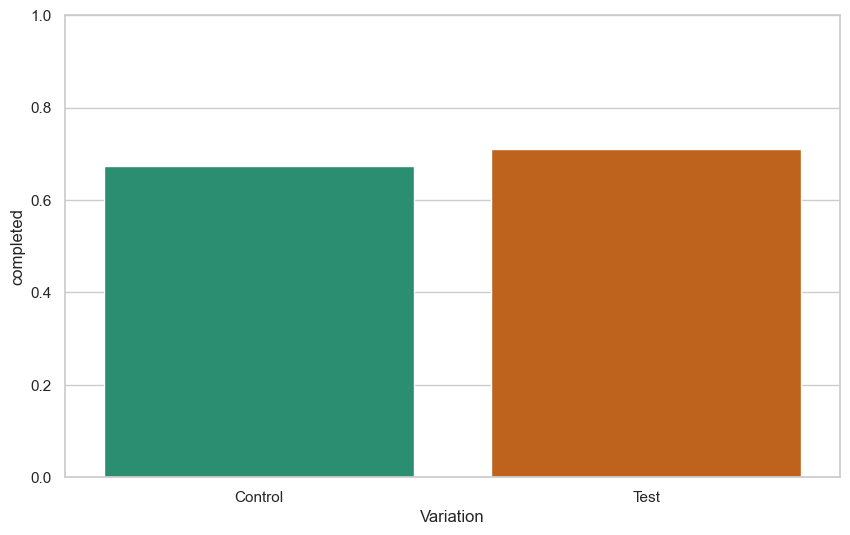

In [44]:
completion_per_visit = df_combined.groupby(['visit_id', 'Variation'])['completed'].max().reset_index()
completion_rate_variation = completion_per_visit.groupby('Variation')['completed'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=completion_rate_variation, x="Variation", y="completed", palette="Dark2")
plt.ylim(0, 1)
plt.show()

TENURE AND VARIATION COMBINED

In [45]:
tenure_var_completion = (
    df_combined.groupby(["tenure_category", "Variation"])["completed"]
    .mean()
    .reset_index()
)
tenure_var_completion

,tenure_category,Variation,completed
0,Long-standing,Control,0.766509
1,Long-standing,Test,0.764973
2,New,Control,0.785017
3,New,Test,0.758051


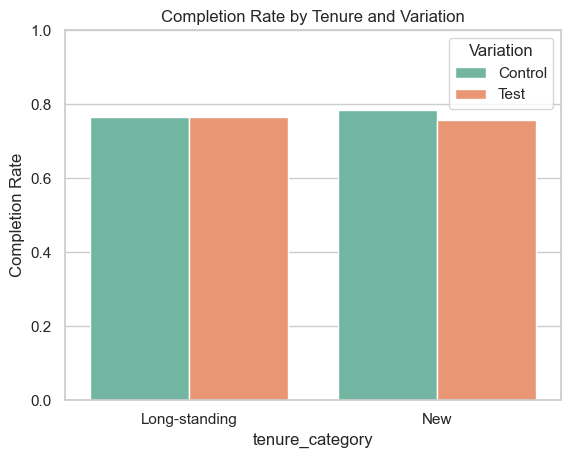

In [46]:
sns.barplot(
    data=tenure_var_completion,
    x="tenure_category",
    y="completed",
    hue="Variation",
    palette="Set2"
)
plt.title("Completion Rate by Tenure and Variation")
plt.ylabel("Completion Rate")
plt.ylim(0, 1)
plt.show()

BY AGE GROUP

In [47]:
age_completion_combined = (
    df_combined.groupby("age_group")["completed"]
    .mean()
    .reset_index()
)
age_completion_combined

/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/4214901016.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_combined.groupby("age_group")["completed"]


,age_group,completed
0,18-30,0.799572
1,31-45,0.790365
2,46-60,0.764308
3,61-80,0.728038


/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/3201482359.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


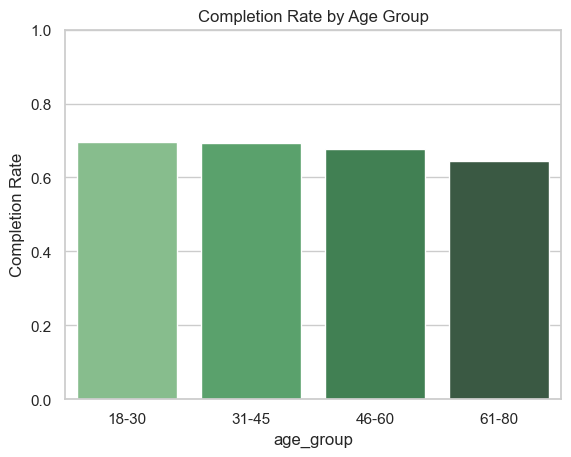

In [48]:
sns.barplot(
    data=age_completion,
    x="age_group",
    y="completed",
    palette="Greens_d"
)
plt.title("Completion Rate by Age Group")
plt.ylabel("Completion Rate")
plt.ylim(0, 1)
plt.show()

/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/1371925101.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_combined.groupby(["process_step", "age_group"])["step_duration"]


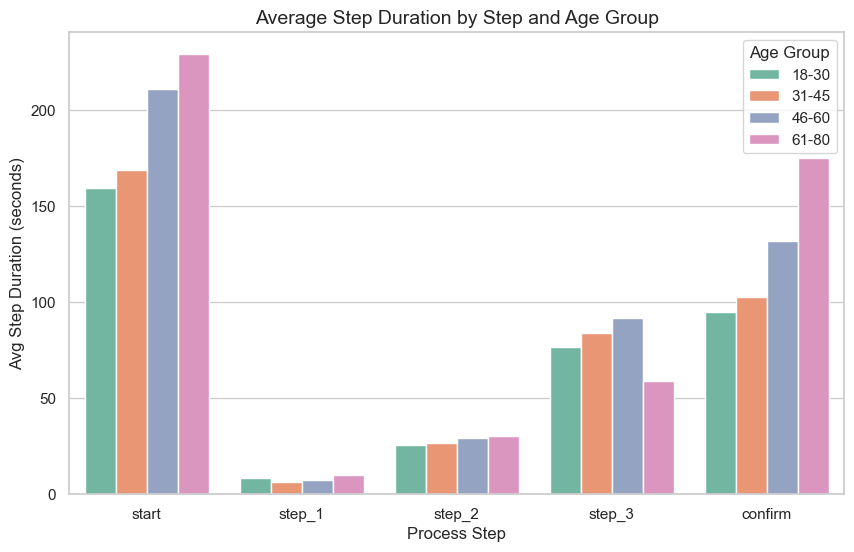

In [49]:
step_age = (
    df_combined.groupby(["process_step", "age_group"])["step_duration"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=step_age, 
    x="process_step", y="step_duration", hue="age_group", palette="Set2"
)
plt.title("Average Step Duration by Step and Age Group", fontsize=14)
plt.ylabel("Avg Step Duration (seconds)")
plt.xlabel("Process Step")
plt.legend(title="Age Group")
plt.show()

/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/1438104962.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_combined.groupby(["process_step", "tenure_category"])["step_duration"]


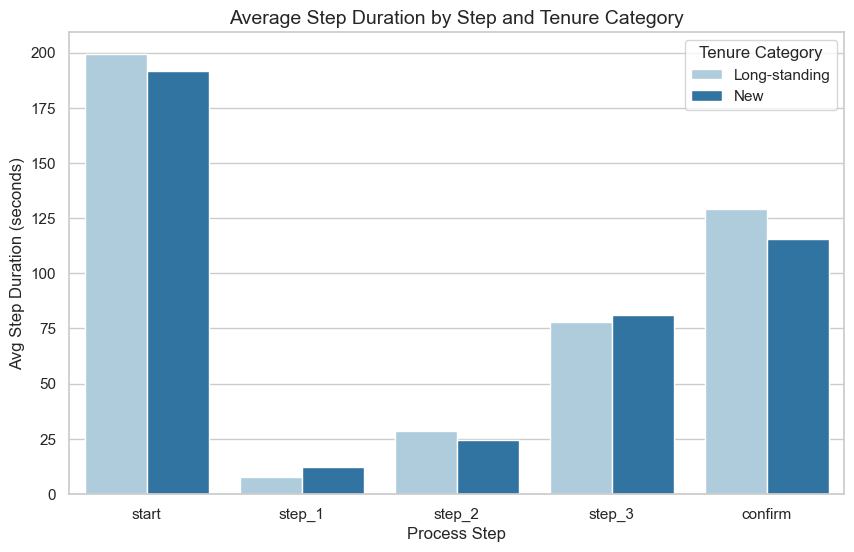

In [50]:
step_tenure = (
    df_combined.groupby(["process_step", "tenure_category"])["step_duration"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=step_tenure, 
    x="process_step", y="step_duration", hue="tenure_category", palette="Paired"
)
plt.title("Average Step Duration by Step and Tenure Category", fontsize=14)
plt.ylabel("Avg Step Duration (seconds)")
plt.xlabel("Process Step")
plt.legend(title="Tenure Category")
plt.show()

/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/830390055.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_combined.groupby(["process_step", "Variation"])["step_duration"]


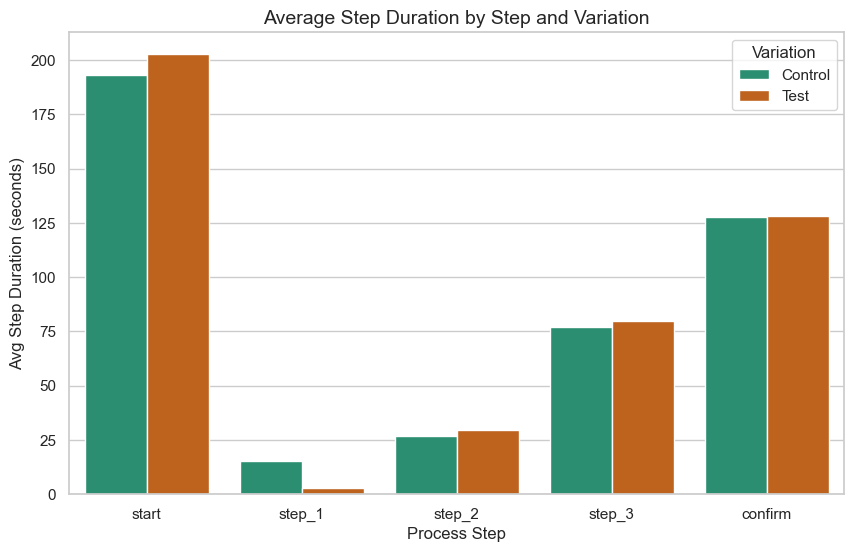

In [51]:
step_variation = (
    df_combined.groupby(["process_step", "Variation"])["step_duration"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=step_variation, 
    x="process_step", y="step_duration", hue="Variation", palette="Dark2"
)
plt.title("Average Step Duration by Step and Variation", fontsize=14)
plt.ylabel("Avg Step Duration (seconds)")
plt.xlabel("Process Step")
plt.legend(title="Variation")
plt.show()

/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/867181441.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_combined.groupby(["process_step", "Variation"])["error_flag"]


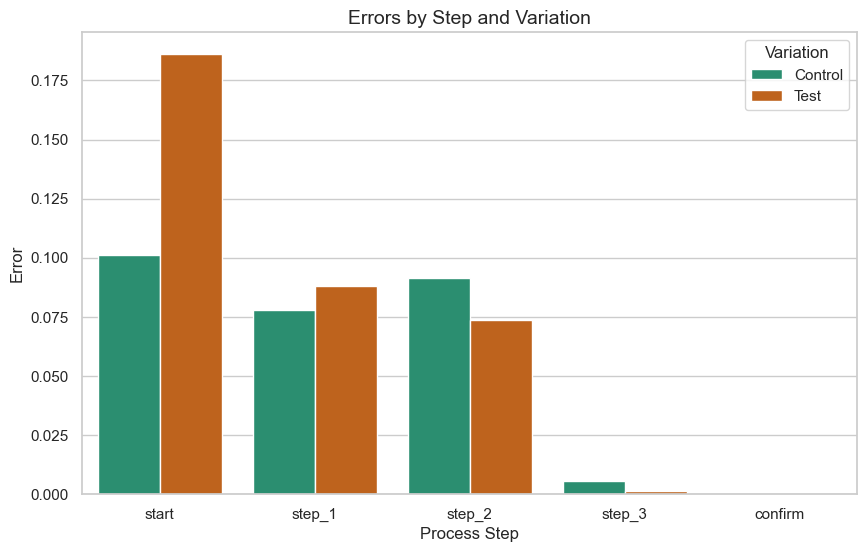

In [52]:
step_variation = (
    df_combined.groupby(["process_step", "Variation"])["error_flag"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=step_variation, 
    x="process_step", y="error_flag", hue="Variation", palette="Dark2"
)
plt.title("Errors by Step and Variation", fontsize=14)
plt.ylabel("Error")
plt.xlabel("Process Step")
plt.legend(title="Variation")
plt.show()

INSIGHTS

Test version takes slightly longer than Control.

Test version is more error prone than Control.

Users are tend to complete the Test version more. Test: %71 , Control: %67

Users are used to the older version, therefore test version has longer comp. time and more errors.

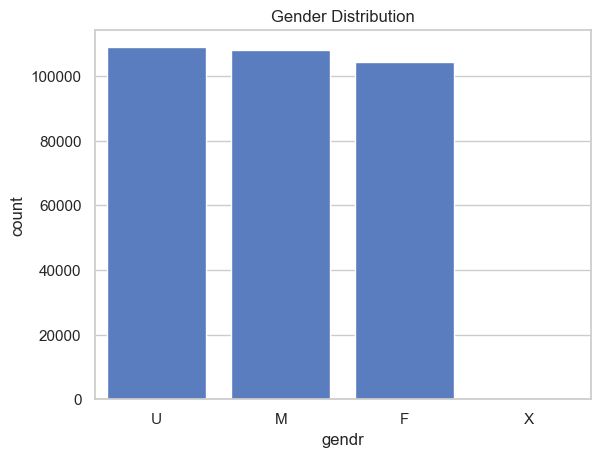

In [53]:
sns.countplot(data=df_combined, x="gendr")
plt.title("Gender Distribution")
plt.show()

NEXT STEPS

Null Hypothesis (H₀)

Alternative Hypothesis (H₁)

Significance level (0,05)

Statistical test 

Calculate p-value

In [54]:
df_combined.head(10)

,client_id,visitor_id,visit_id,process_step,date_time,Date,Time,step_num,error_flag,step_duration,...,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,tenure_category,completed,age_group
12,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,2017-04-15,12:57:56,0,0,NaN,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30
13,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,2017-04-15,12:58:03,1,0,7.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30
14,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,2017-04-15,12:58:35,2,0,32.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30
15,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,2017-04-15,13:00:14,3,0,99.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30
16,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,2017-04-15,13:00:34,4,0,20.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30
17,647,66758770_53988066587,40369564_40101682850_311847,start,2017-04-12 15:41:28,2017-04-12,15:41:28,0,0,NaN,...,57.5,M,2.0,30525.80,0.0,4.0,Test,Long-standing,1.0,46-60
18,647,66758770_53988066587,40369564_40101682850_311847,step_1,2017-04-12 15:41:35,2017-04-12,15:41:35,1,0,7.0,...,57.5,M,2.0,30525.80,0.0,4.0,Test,Long-standing,1.0,46-60
19,647,66758770_53988066587,40369564_40101682850_311847,step_2,2017-04-12 15:41:53,2017-04-12,15:41:53,2,0,18.0,...,57.5,M,2.0,30525.80,0.0,4.0,Test,Long-standing,1.0,46-60
20,647,66758770_53988066587,40369564_40101682850_311847,step_3,2017-04-12 15:45:02,2017-04-12,15:45:02,3,0,189.0,...,57.5,M,2.0,30525.80,0.0,4.0,Test,Long-standing,1.0,46-60
21,647,66758770_53988066587,40369564_40101682850_311847,confirm,2017-04-12 15:47:45,2017-04-12,15:47:45,4,0,163.0,...,57.5,M,2.0,30525.80,0.0,4.0,Test,Long-standing,1.0,46-60


In [55]:
import pandas as pd
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df_combined['Variation'], df_combined['completed'])

print(contingency_table)

### 1 = completed
### 0 = not completed

completed    0.0     1.0
Variation               
Control    33300  110162
Test       41888  135959


In [56]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)
print("Expected frequencies:\n", expected)

alpha = 0.05
if p < alpha:
    print("Reject H0: Completion depends on group (Test > Control).")
else:
    print("Fail to reject H0.")

Chi-square statistic: 5.135549497418362
Degrees of freedom: 1
P-value: 0.023440665718217426
Expected frequencies:
 [[ 33570.86435799 109891.13564201]
 [ 41617.13564201 136229.86435799]]
Reject H0: Completion depends on group (Test > Control).


In [57]:
df_combined.head()

,client_id,visitor_id,visit_id,process_step,date_time,Date,Time,step_num,error_flag,step_duration,...,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,tenure_category,completed,age_group
12,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,2017-04-15,12:57:56,0,0,NaN,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30
13,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,2017-04-15,12:58:03,1,0,7.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30
14,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,2017-04-15,12:58:35,2,0,32.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30
15,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,2017-04-15,13:00:14,3,0,99.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30
16,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,2017-04-15,13:00:34,4,0,20.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30


In [58]:
### 

error_rate_per_step = df_final_web_data.groupby('step_num')['error_flag'].mean()
print(error_rate_per_step)

step_num
0    0.159470
1    0.088031
2    0.070922
3    0.002272
4    0.000000
Name: error_flag, dtype: float64


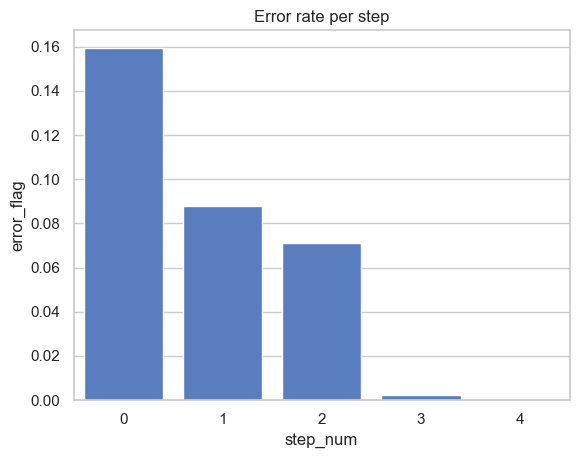

In [59]:
sns.barplot(data = error_rate_per_step)
plt.title("Error rate per step")
plt.show()

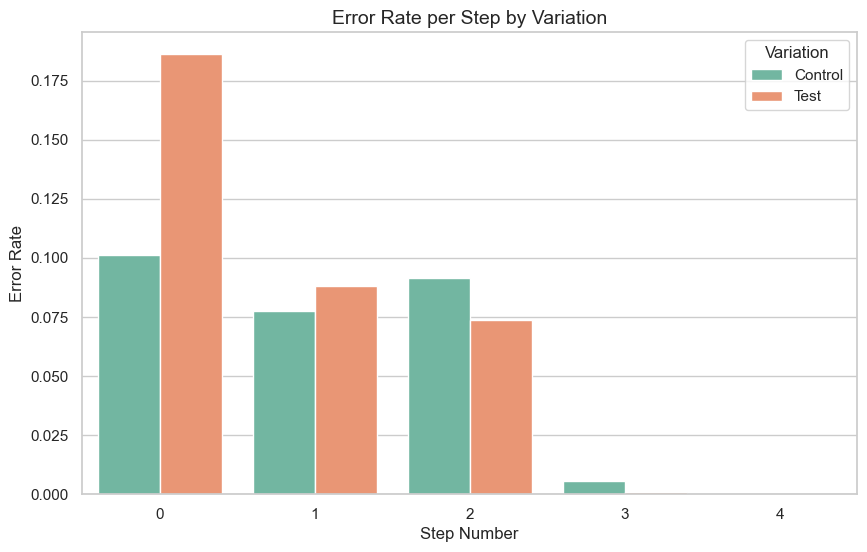

In [60]:
error_rate_step_var = (
    df_combined.groupby(['step_num', 'Variation'])['error_flag']
    .mean()
    .reset_index()
)

# Label the steps as numbers
step_labels = {
    0: "start",
    1: "step_1",
    2: "step_2",
    3: "step_3",
    4: "confirm"
}

# Add a column with labels
error_rate_step_var["step_name"] = error_rate_step_var["step_num"].map(step_labels)


plt.figure(figsize=(10,6))
sns.barplot(
    data=error_rate_step_var,
    x="step_num",
    y="error_flag",
    hue="Variation",   # separate bars for each variation
    palette="Set2"
)

plt.title("Error Rate per Step by Variation", fontsize=14)
plt.ylabel("Error Rate")
plt.xlabel("Step Number")
plt.legend(title="Variation")

plt.show()

In [61]:
error_rate_step_var.head(10), error_rate_step_var.columns

(   step_num Variation  error_flag step_name
 0         0   Control    0.101117     start
 1         0      Test    0.186174     start
 2         1   Control    0.077659    step_1
 3         1      Test    0.088114    step_1
 4         2   Control    0.091439    step_2
 5         2      Test    0.073833    step_2
 6         3   Control    0.005703    step_3
 7         3      Test    0.001120    step_3
 8         4   Control    0.000000   confirm
 9         4      Test    0.000000   confirm,
 Index(['step_num', 'Variation', 'error_flag', 'step_name'], dtype='object'))

-Start page error rates are higher than the rest

-

In [62]:
error_rate_step_var_dur = (
    df_combined.groupby(['step_num', 'Variation'])['step_duration']
    .mean()
    .reset_index()
)

In [63]:
error_rate_step_var_dur

,step_num,Variation,step_duration
0,0,Control,193.204193
1,0,Test,202.762718
2,1,Control,15.142852
3,1,Test,2.902846
4,2,Control,26.935694
5,2,Test,29.654428
6,3,Control,76.807913
7,3,Test,79.659901
8,4,Control,127.664397
9,4,Test,128.106290


In [64]:
# Average step duration per step and variation
step_duration_summary = (
    df_combined.groupby(['step_num', 'Variation'])['step_duration']
    .mean()
    .reset_index()
    .rename(columns={'step_duration': 'avg_step_duration'})
)

# Error rate per step and variation
error_flag_summary = (
    df_combined.groupby(['step_num', 'Variation'])['error_flag']
    .mean()
    .reset_index()
    .rename(columns={'error_flag': 'error_rate'})
)

# Merge both summaries into one dataframe
error_rate_step_var_dur = pd.merge(
    step_duration_summary,
    error_flag_summary,
    on=['step_num', 'Variation'],
    how='left'
)

error_rate_step_var_dur.head(10)

,step_num,Variation,avg_step_duration,error_rate
0,0,Control,193.204193,0.101117
1,0,Test,202.762718,0.186174
2,1,Control,15.142852,0.077659
3,1,Test,2.902846,0.088114
4,2,Control,26.935694,0.091439
5,2,Test,29.654428,0.073833
6,3,Control,76.807913,0.005703
7,3,Test,79.659901,0.001120
8,4,Control,127.664397,0.000000
9,4,Test,128.106290,0.000000


In [65]:
import pandas as pd
from scipy.stats import chi2_contingency

# Build contingency table of error_flag counts per Variation
contingency_table = pd.crosstab(df_combined['Variation'], df_combined['error_flag'])

print(contingency_table)

error_flag       0      1
Variation                
Control     133847   9615
Test        161600  16247


In [66]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)
print("Expected frequencies:\n", expected)


Chi-square: 634.9153987288392
Degrees of freedom: 1
P-value: 4.263573094460468e-140
Expected frequencies:
 [[131914.81568832  11547.18431168]
 [163532.18431168  14314.81568832]]


In [67]:
### gender distribution
df_combined['gendr'].value_counts(normalize=True)

gendr
U    0.338984
M    0.336272
F    0.324719
X    0.000025
Name: proportion, dtype: float64

In [68]:
### tenure distribution
df_combined['tenure_category'].value_counts(normalize=True)

tenure_category
Long-standing    0.92674
New              0.07326
Name: proportion, dtype: float64

In [69]:
### age group distribution
df_combined['age_group'].value_counts(normalize=True)

age_group
46-60    0.322785
61-80    0.257846
31-45    0.254042
18-30    0.165327
Name: proportion, dtype: float64

In [70]:
### avg num of accounts
df_combined['num_accts'].mean()

np.float64(2.2629519281958363)

### Age Group vs Completion Rate.


We want to know if completion rates differ by age group.

Null Hypothesis (H₀):
Completion rate is the same across all age groups.
(Age group does not affect completion.)

Alternative Hypothesis (H₁):
At least one age group has a different completion rate.
(Age group affects completion.)

In [71]:
contingency_table = pd.crosstab(df_combined['age_group'], df_combined['completed'])

contingency_table

completed,0.0,1.0
age_group,,
18-30,10486,41832
31-45,16853,63539
46-60,24075,78071
61-80,22191,59405


In [72]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)
print("Expected frequencies:\n", expected)

Chi-square: 1254.6361321439776
Degrees of freedom: 3
P-value: 1.0251093679633894e-271
Expected frequencies:
 [[12168.87992492 40149.12007508]
 [18698.73838686 61693.26161314]
 [23758.59950324 78387.40049676]
 [18978.78218498 62617.21781502]]


p ≥ 0.05, fail to reject H₀ → No evidence that completion rate differs by age group

### Completion Rate vs Variation

Does completion rate differ significantly across different variations of the product?

Null Hypothesis (H₀): Completion rate is independent of variation (all variations have the same completion likelihood).

Alternative Hypothesis (H₁): Completion rate depends on variation (at least one variation has a different completion rate).

In [73]:
completion_rates = df_combined.groupby('Variation')['completed'].mean().reset_index()
completion_rates

,Variation,completed
0,Control,0.767883
1,Test,0.764472


In [74]:
contingency = pd.crosstab(df_combined['Variation'], df_combined['completed'])
contingency

completed,0.0,1.0
Variation,,
Control,33300,110162
Test,41888,135959


In [75]:
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square Statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)
print("Expected frequencies:\n", expected)

Chi-square Statistic: 5.135549497418362
Degrees of freedom: 1
P-value: 0.023440665718217426
Expected frequencies:
 [[ 33570.86435799 109891.13564201]
 [ 41617.13564201 136229.86435799]]


p < 0.05 → reject H₀ → Completion rate varies significantly across variations.

Pearson for: clnt_age, bal, calls_6_mnth, logons_6_mnth vs. step_duration. Continuous

Spearman for: age_group vs. completion, tenure_category vs. step_duration, step_num vs. error_flag.

In [76]:
from scipy.stats import pearsonr

# Select the two columns
subset = df_combined[['clnt_age', 'step_duration']].copy()

# Remove NaN or inf values
subset = subset.replace([np.inf, -np.inf], np.nan).dropna()

# Run Pearson correlation
pearson_corr, p_value = pearsonr(subset['clnt_age'], subset['step_duration'])
print("Pearson correlation:", pearson_corr, "P-value:", p_value)

Pearson correlation: 0.025553733697503474 P-value: 1.2025543331866984e-37


In [77]:
from scipy.stats import spearmanr

spearman_corr, p_value = spearmanr(subset['clnt_age'], subset['step_duration'])
print("Spearman correlation:", spearman_corr, "P-value:", p_value)

Spearman correlation: 0.09987133726527499 P-value: 0.0


 Pearson Correlation:
   Coefficient = 0.026, P-value = 0.0000

Spearman Correlation:
   Coefficient = 0.100, P-value = 0.0000


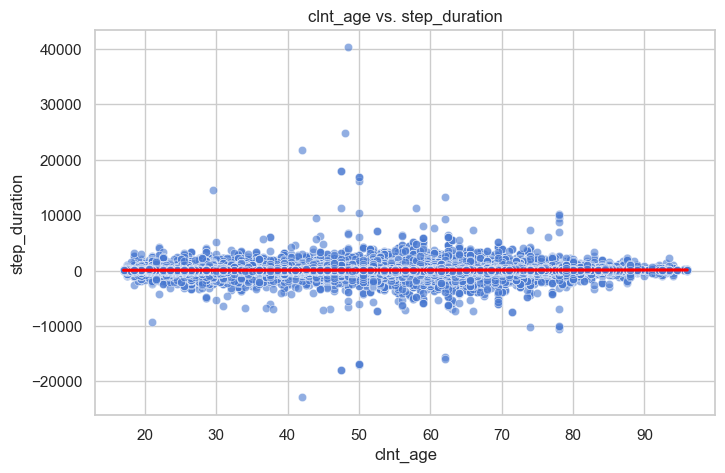

In [78]:


# Pick the two variables
subset = df_combined[['clnt_age', 'step_duration']].copy()

# Remove NaN and inf values
subset = subset.replace([np.inf, -np.inf], np.nan).dropna()

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(subset['clnt_age'], subset['step_duration'])

# Spearman correlation (monotonic relationship, ranks)
spearman_corr, spearman_p = spearmanr(subset['clnt_age'], subset['step_duration'])

print(" Pearson Correlation:")
print(f"   Coefficient = {pearson_corr:.3f}, P-value = {pearson_p:.4f}")
print("\n" "Spearman Correlation:")
print(f"   Coefficient = {spearman_corr:.3f}, P-value = {spearman_p:.4f}")

# Visualization: scatterplot with regression line
plt.figure(figsize=(8,5))
sns.scatterplot(data=subset, x='clnt_age', y='step_duration', alpha=0.6)
sns.regplot(data=subset, x='clnt_age', y='step_duration', scatter=False, color="red")
plt.title("clnt_age vs. step_duration")
plt.show()

In [79]:
from statsmodels.stats.proportion import proportions_ztest

In [80]:
### h0: error rates are the same in both control and test groups
### h1: error rates are not the same in both control and test groups
completed_counts = df_combined.groupby('Variation')['error_flag'].sum().values
# Total users in each group
n_counts = df_combined.groupby('Variation')['error_flag'].count().values
# Run proportions z-test
z_stat, p_val = proportions_ztest(completed_counts, n_counts, alternative='two-sided')
print("Z-statistic:", z_stat)
print("P-value:", p_val)

Z-statistic: -25.204049796278067
P-value: 3.616424613022473e-140


In [81]:
error_counts = df_combined.groupby('Variation')['error_flag'].sum()
total_counts = df_combined.groupby('Variation')['error_flag'].count()
error_rates = error_counts / total_counts
print(error_rates)

Variation
Control    0.067021
Test       0.091354
Name: error_flag, dtype: float64


In [82]:
avg_age = df_combined.groupby('Variation')['clnt_age'].mean()
print(avg_age)

Variation
Control    48.309896
Test       48.750018
Name: clnt_age, dtype: float64


In [83]:
from scipy.stats import ttest_ind
### h0: mean age of the control variation == mean age of the test variation

### h1: h0: mean age of the control variation != mean age of the test variation
control_age = df_combined[df_combined['Variation'] == 'Control']['clnt_age'].dropna()
test_age = df_combined[df_combined['Variation'] == 'Test']['clnt_age'].dropna()
# Run proportions z-test
t_stat, p_value = ttest_ind(control_age, test_age, equal_var=False)
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -7.928355666370457
p-value: 2.2280417023457808e-15


In [84]:
df_combined_clean = pd.read_csv("/Users/lewisclark/Downloads/df_combined_clean.csv", delimiter=",")

In [85]:
df_combined_clean.head()

,client_id,visitor_id,visit_id,process_step,date_time,Date,Time,step_num,error_flag,step_duration,...,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,tenure_category,completed,age_group
0,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,2017-04-15,12:58:03,1,0,7.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30
1,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,2017-04-15,12:58:35,2,0,32.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30
2,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,2017-04-15,13:00:14,3,0,99.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30
3,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,2017-04-15,13:00:34,4,0,20.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30
4,647,66758770_53988066587,40369564_40101682850_311847,step_1,2017-04-12 15:41:35,2017-04-12,15:41:35,1,0,7.0,...,57.5,M,2.0,30525.80,0.0,4.0,Test,Long-standing,1.0,46-60


In [86]:
import pandas as pd
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df_combined_clean['Variation'], df_combined_clean['completed'])

print(contingency_table)

### 1 = completed
### 0 = not completed

completed    0.0     1.0
Variation               
Control    22243   87312
Test       30498  108107


In [87]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)
print("Expected frequencies:\n", expected)

alpha = 0.05
if p < alpha:
    print("Reject H0: Completion depends on group (Test > Control).")
else:
    print("Fail to reject H0.")

Chi-square statistic: 105.62311656407981
Degrees of freedom: 1
P-value: 8.918124928935226e-25
Expected frequencies:
 [[ 23283.52778449  86271.47221551]
 [ 29457.47221551 109147.52778449]]
Reject H0: Completion depends on group (Test > Control).


In [88]:
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

# Your contingency table
contingency_table = pd.crosstab(df_combined_clean['Variation'], df_combined_clean['completed'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Cramér's V calculation
n = contingency_table.sum().sum()  # total sample size
phi2 = chi2 / n
r, k = contingency_table.shape
cramers_v = np.sqrt(phi2 / min(r-1, k-1))

print("Cramér's V:", cramers_v)

Cramér's V: 0.0206306826534553


In [89]:
completion_rates = df_combined_clean.groupby("Variation")["completed"].mean() * 100

print("Completion rates (%):")
print(completion_rates)

Completion rates (%):
Variation
Control    79.696956
Test       77.996465
Name: completed, dtype: float64


In [ ]:
age_completion_combined = (
    df_combined_clean.groupby("age_group")["completed"]
    .mean()
    .reset_index()
)
age_completion_combined

In [90]:
df_combined_clean.head()

,client_id,visitor_id,visit_id,process_step,date_time,Date,Time,step_num,error_flag,step_duration,...,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,tenure_category,completed,age_group
0,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,2017-04-15,12:58:03,1,0,7.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30
1,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,2017-04-15,12:58:35,2,0,32.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30
2,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,2017-04-15,13:00:14,3,0,99.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30
3,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,2017-04-15,13:00:34,4,0,20.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,18-30
4,647,66758770_53988066587,40369564_40101682850_311847,step_1,2017-04-12 15:41:35,2017-04-12,15:41:35,1,0,7.0,...,57.5,M,2.0,30525.80,0.0,4.0,Test,Long-standing,1.0,46-60


/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/1978068296.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_completion = df_merged.groupby("age_group")["completed"].mean().reset_index()
/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/1978068296.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_completion, x="age_group", y="completed", palette="viridis")


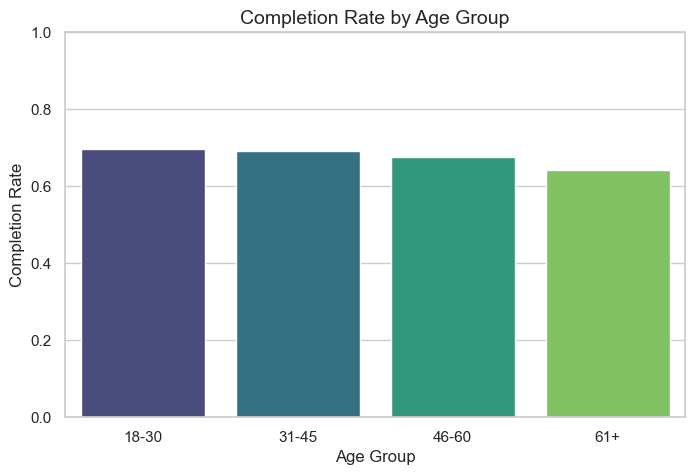

In [102]:
df_combined_clean["age_group"] = pd.cut(df_merged["clnt_age"], bins=[18,30,45,60,np.inf], labels=["18-30","31-45","46-60","61+"])

age_completion = df_merged.groupby("age_group")["completed"].mean().reset_index()

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=age_completion, x="age_group", y="completed", palette="viridis")
plt.title("Completion Rate by Age Group", fontsize=14)
plt.ylabel("Completion Rate")
plt.ylim(0,1)
plt.xlabel("Age Group")
plt.show()

In [103]:
contingency_table = pd.crosstab(df_combined_clean['age_group'], df_combined_clean['completed'])

contingency_table

completed,0.0,1.0
age_group,,
18-30,2903,10593
31-45,3971,15011
46-60,4641,17446
61+,3306,12195


/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/711776582.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  completion_by_age = df_combined_clean.groupby(["age_group", "Variation"])["completed"].mean().reset_index()


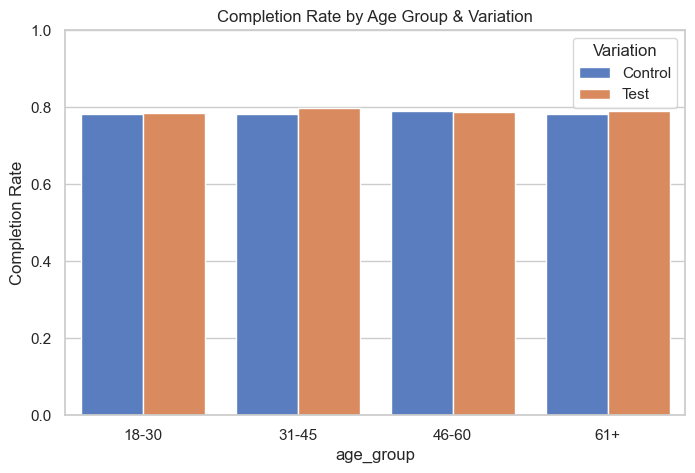

In [104]:
completion_by_age = df_combined_clean.groupby(["age_group", "Variation"])["completed"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=completion_by_age, x="age_group", y="completed", hue="Variation")
plt.title("Completion Rate by Age Group & Variation")
plt.ylabel("Completion Rate")
plt.ylim(0,1)
plt.show()

In [105]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)
print("Expected frequencies:\n", expected)

Chi-square: 2.196029067939329
Degrees of freedom: 3
P-value: 0.5327309444672395
Expected frequencies:
 [[ 2854.79713413 10641.20286587]
 [ 4015.24593954 14966.75406046]
 [ 4672.04388719 17414.95611281]
 [ 3278.91303913 12222.08696087]]


In [106]:
import numpy as np
from scipy.stats import chi2_contingency
import pandas as pd

# Create the contingency table
contingency_table = pd.crosstab(df_combined_clean["age_group"], df_combined_clean["completed"])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Cramér's V
n = contingency_table.sum().sum()
phi2 = chi2 / n
r, k = contingency_table.shape
cramers_v = np.sqrt(phi2 / min(r-1, k-1))

print("Cramér's V:", cramers_v)

Cramér's V: 0.00559841875205183


In [107]:
# Average step duration per step and variation
step_duration_summary = (
    df_combined_clean.groupby(['step_num', 'Variation'])['step_duration']
    .mean()
    .reset_index()
    .rename(columns={'step_duration': 'avg_step_duration'})
)

# Error rate per step and variation
error_flag_summary = (
    df_combined_clean.groupby(['step_num', 'Variation'])['error_flag']
    .mean()
    .reset_index()
    .rename(columns={'error_flag': 'error_rate'})
)

# Merge both summaries into one dataframe
error_rate_step_var_dur = pd.merge(
    step_duration_summary,
    error_flag_summary,
    on=['step_num', 'Variation'],
    how='left'
)

error_rate_step_var_dur.head(10)

,step_num,Variation,avg_step_duration,error_rate
0,0,Control,193.289998,0.287055
1,0,Test,202.652928,0.445234
2,1,Control,14.925748,0.077673
3,1,Test,2.658104,0.086924
4,2,Control,26.711757,0.091059
5,2,Test,29.523455,0.072917
6,3,Control,77.254488,0.005641
7,3,Test,80.103992,0.001067
8,4,Control,127.114032,0.000000
9,4,Test,127.734065,0.000000


In [110]:
## ttest step 0 

from scipy.stats import ttest_ind

# Example for step 0
step0 = df_combined_clean[df_combined_clean['step_num'] == 0]
t_stat, p_val = ttest_ind(
    step0[step0['Variation'] == 'Control']['step_duration'],
    step0[step0['Variation'] == 'Test']['step_duration'],
    equal_var=False  
)
print(f"Step 0: t-stat={t_stat:.3f}, p-value={p_val:.3f}")

Step 0: t-stat=-1.838, p-value=0.066


In [112]:
### ttest step 1

step1 = df_combined_clean[df_combined_clean['step_num'] == 1]
t_stat, p_val = ttest_ind(
    step1[step1['Variation'] == 'Control']['step_duration'],
    step1[step1['Variation'] == 'Test']['step_duration'],
    equal_var=False  
)
print(f"Step 1: t-stat={t_stat:.3f}, p-value={p_val:.3f}")

Step 1: t-stat=3.574, p-value=0.000


In [113]:
### ttest setp 2

step2 = df_combined_clean[df_combined_clean['step_num'] == 2]
t_stat, p_val = ttest_ind(
    step2[step2['Variation'] == 'Control']['step_duration'],
    step2[step2['Variation'] == 'Test']['step_duration'],
    equal_var=False  
)
print(f"Step 2: t-stat={t_stat:.3f}, p-value={p_val:.3f}")

Step 2: t-stat=-0.939, p-value=0.348


In [114]:
### ttest step 3

step3 = df_combined_clean[df_combined_clean['step_num'] == 3]
t_stat, p_val = ttest_ind(
    step3[step3['Variation'] == 'Control']['step_duration'],
    step3[step3['Variation'] == 'Test']['step_duration'],
    equal_var=False  
)
print(f"Step 3: t-stat={t_stat:.3f}, p-value={p_val:.3f}")

Step 3: t-stat=-1.012, p-value=0.312


In [115]:
### ttest step 4

step4 = df_combined_clean[df_combined_clean['step_num'] == 3]
t_stat, p_val = ttest_ind(
    step4[step4['Variation'] == 'Control']['step_duration'],
    step4[step4['Variation'] == 'Test']['step_duration'],
    equal_var=False  
)
print(f"Step 4: t-stat={t_stat:.3f}, p-value={p_val:.3f}")

Step 4: t-stat=-1.012, p-value=0.312


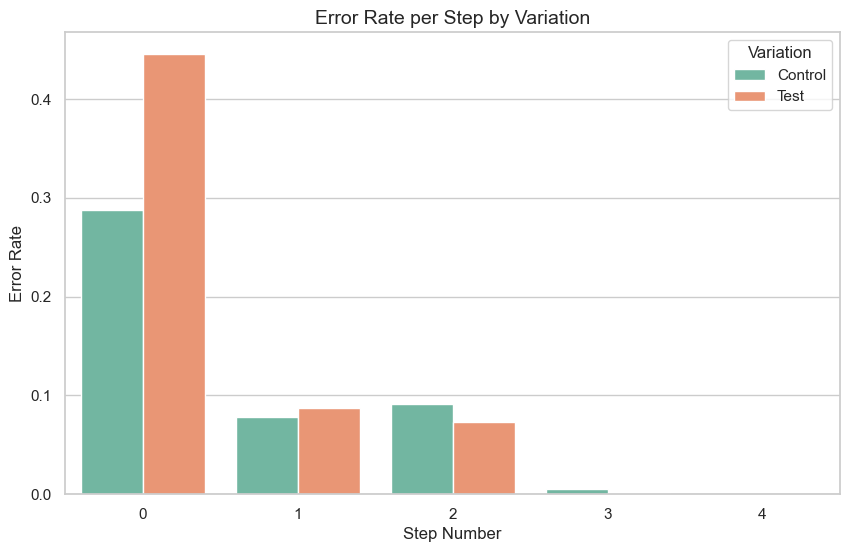

In [116]:
error_rate_step_var = (
    df_combined_clean.groupby(['step_num', 'Variation'])['error_flag']
    .mean()
    .reset_index()
)

# Label the steps as numbers
step_labels = {
    0: "start",
    1: "step_1",
    2: "step_2",
    3: "step_3",
    4: "confirm"
}

# Add a column with labels
error_rate_step_var["step_name"] = error_rate_step_var["step_num"].map(step_labels)


plt.figure(figsize=(10,6))
sns.barplot(
    data=error_rate_step_var,
    x="step_num",
    y="error_flag",
    hue="Variation",   # separate bars for each variation
    palette="Set2"
)

plt.title("Error Rate per Step by Variation", fontsize=14)
plt.ylabel("Error Rate")
plt.xlabel("Step Number")
plt.legend(title="Variation")

plt.show()

In [117]:
from scipy.stats import chi2_contingency

# Store results in a list
results = []

for step in sorted(df_combined_clean['step_num'].unique()):
    step_data = df_combined_clean[df_combined_clean['step_num'] == step]
    contingency_table = pd.crosstab(step_data['Variation'], step_data['error_flag'])
    
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    results.append({
        "step_num": step,
        "Chi2": chi2,
        "p_value": p,
        "Significant": p < 0.05
    })

# Convert to DataFrame for easy viewing
results_df = pd.DataFrame(results)
print(results_df)

   step_num         Chi2        p_value  Significant
0         0  1012.271787  3.862228e-222         True
1         1    18.354135   1.834205e-05         True
2         2    60.826962   6.231854e-15         True
3         3    76.102201   2.693569e-18         True
4         4     0.000000   1.000000e+00        False


In [118]:
import numpy as np
from scipy.stats import chi2_contingency

# Store results
results = []

for step in sorted(df_combined_clean['step_num'].unique()):
    step_data = df_combined_clean[df_combined_clean['step_num'] == step]
    contingency_table = pd.crosstab(step_data['Variation'], step_data['error_flag'])
    
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    # Cramér's V calculation
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    cramers_v = np.sqrt(phi2 / min(r-1, k-1))
    
    results.append({
        "step_num": step,
        "Chi2": chi2,
        "p_value": p,
        "Cramers_V": cramers_v
    })

results_df = pd.DataFrame(results)
print(results_df)

   step_num         Chi2        p_value  Cramers_V
0         0  1012.271787  3.862228e-222   0.160575
1         1    18.354135   1.834205e-05   0.016569
2         2    60.826962   6.231854e-15   0.033016
3         3    76.102201   2.693569e-18   0.039970
4         4     0.000000   1.000000e+00        NaN


/var/folders/sp/zmqgkgsj1992h0k71dlr78_80000gn/T/ipykernel_33570/2695417474.py:17: RuntimeWarning: invalid value encountered in scalar divide
  cramers_v = np.sqrt(phi2 / min(r-1, k-1))


In [119]:
df_combined_clean['Variation'].value_counts()

Variation
Test       138605
Control    109555
Name: count, dtype: int64

In [120]:
df_final_web_data.shape

(755405, 10)

In [122]:
import random

print(random.choice(["Heads", "Tails"]))

Heads


In [125]:
df_combined_clean.head()

,client_id,visitor_id,visit_id,process_step,date_time,Date,Time,step_num,error_flag,step_duration,...,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,tenure_category,completed,age_group
0,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,2017-04-15,12:58:03,1,0,7.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,61+
1,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,2017-04-15,12:58:35,2,0,32.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,46-60
2,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,2017-04-15,13:00:14,3,0,99.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,31-45
3,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,2017-04-15,13:00:34,4,0,20.0,...,29.5,U,2.0,25454.66,2.0,6.0,Test,New,1.0,46-60
4,647,66758770_53988066587,40369564_40101682850_311847,step_1,2017-04-12 15:41:35,2017-04-12,15:41:35,1,0,7.0,...,57.5,M,2.0,30525.80,0.0,4.0,Test,Long-standing,1.0,31-45


In [126]:
df_combined_clean.columns

Index(['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time',
       'Date', 'Time', 'step_num', 'error_flag', 'step_duration',
       'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts',
       'bal', 'calls_6_mnth', 'logons_6_mnth', 'Variation', 'tenure_category',
       'completed', 'age_group'],
      dtype='object')